## Setup — Imports

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import minimum_filter, maximum_filter

plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)  # fixes the noise pattern so re-running gives the same result for your report
                     # (delete this line if you want a fresh random noise pattern each run)

---
## Problem 1 — Salt & Pepper Noise → Min and Max Filtering

**Idea:** "Pepper" noise (random black pixels) is removed by a **max filter** (it replaces a pixel with the brightest value in its neighbourhood, so isolated dark pixels disappear). "Salt" noise (random white pixels) is removed by a **min filter** (replaces with the darkest neighbour, so isolated bright pixels disappear). Applying max then min cleans up both.

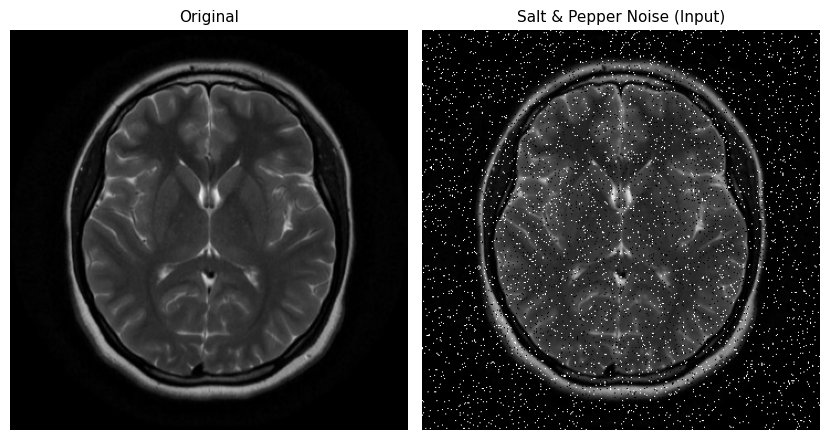

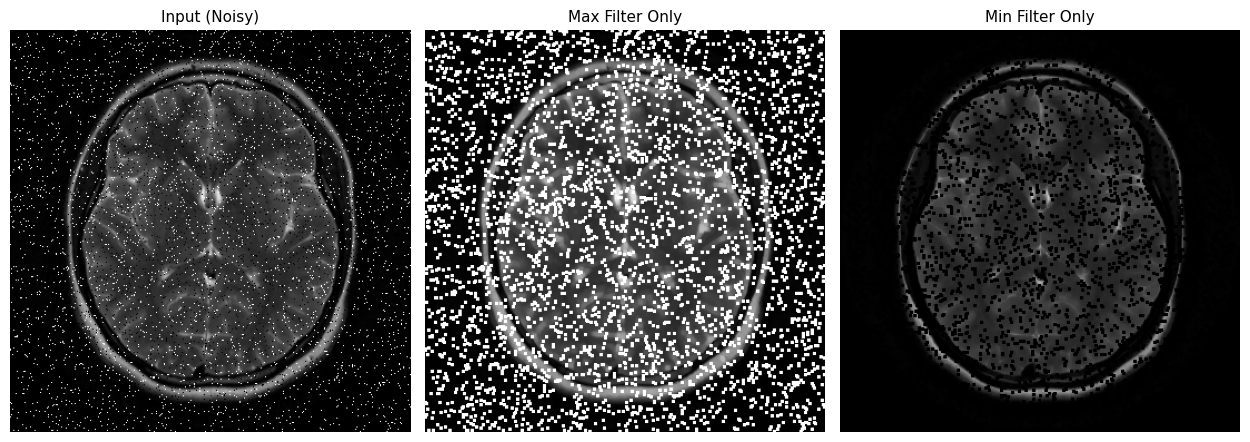

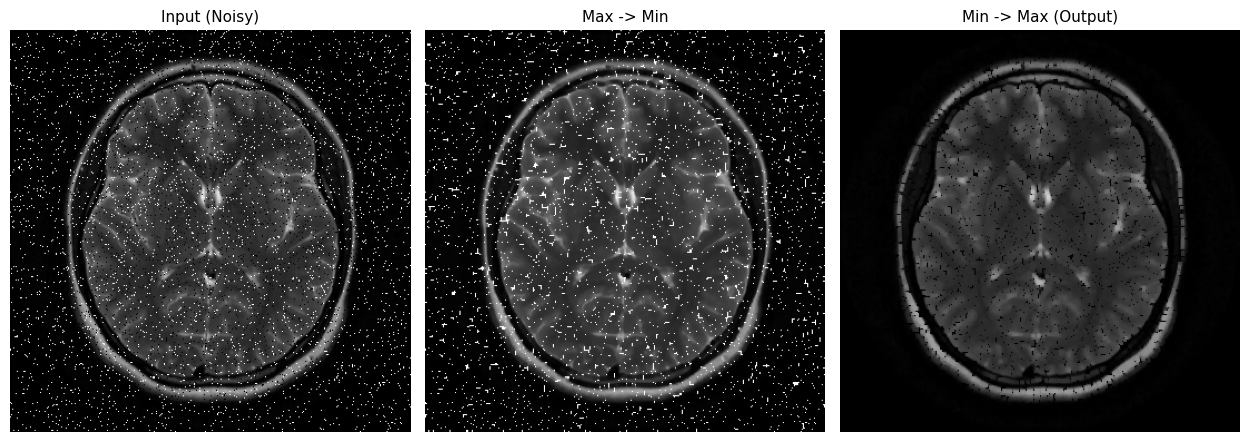

PSNR noisy         vs original: 16.25 dB
PSNR max-filtered  vs original: 7.36 dB
PSNR min-filtered  vs original: 19.99 dB
PSNR max -> min    vs original: 15.45 dB
PSNR min -> max    vs original: 27.00 dB


In [ ]:
img1 = load_gray('image1.png')

noisy1 = add_salt_pepper_noise(img1, salt_prob=0.03, pepper_prob=0.03)

# Max filter -> removes PEPPER (dark) noise ... but DILATES any salt (white) noise present
max_filtered = maximum_filter(noisy1, size=3)

# Min filter -> removes SALT (white) noise ... but DILATES any pepper (black) noise present
min_filtered = minimum_filter(noisy1, size=3)

# Try both orders, since order changes the result when both noise types are mixed together
max_then_min = minimum_filter(maximum_filter(noisy1, size=3), size=3)
min_then_max = maximum_filter(minimum_filter(noisy1, size=3), size=3)

show_images([img1, noisy1], ['Original', 'Salt & Pepper Noise (Input)'])
show_images([noisy1, max_filtered, min_filtered],
            ['Input (Noisy)', 'Max Filter Only', 'Min Filter Only'])
show_images([noisy1, max_then_min, min_then_max],
            ['Input (Noisy)', 'Max -> Min', 'Min -> Max (Output)'])

print(f"PSNR noisy         vs original: {psnr(img1, noisy1):.2f} dB")
print(f"PSNR max-filtered  vs original: {psnr(img1, max_filtered):.2f} dB")
print(f"PSNR min-filtered  vs original: {psnr(img1, min_filtered):.2f} dB")
print(f"PSNR max -> min    vs original: {psnr(img1, max_then_min):.2f} dB")
print(f"PSNR min -> max    vs original: {psnr(img1, min_then_max):.2f} dB")

**Reading the result — and a catch worth reporting honestly:** a max filter only cleans up *pepper* (black) noise — if salt (white) noise is also present in the same image, the max filter actually spreads/enlarges it, because taking the brightest value in a neighbourhood that contains even one white speckle turns the whole neighbourhood bright. The mirror problem happens with the min filter and pepper noise. So when **both** noise types are mixed in together (true "salt-and-pepper" noise), a single min or max pass only fixes one problem while making the other worse — you can see this in the PSNR numbers above, where the single-filter passes can score *worse* than the noisy input itself.

Running both orders (max→min and min→max) and comparing PSNR will tell you which one works better **for this specific image** — it depends on how much of the image is bright vs. dark to begin with (e.g. an MRI/CT scan with a large black background reacts differently to dilation than a high-key image would). This is also exactly why **median filtering** (Problem 3) is generally the preferred technique for true salt-and-pepper noise — it removes both extremes in one pass without dilating either of them.

---
## Problem 2 — Gaussian Noise → Gaussian Filtering

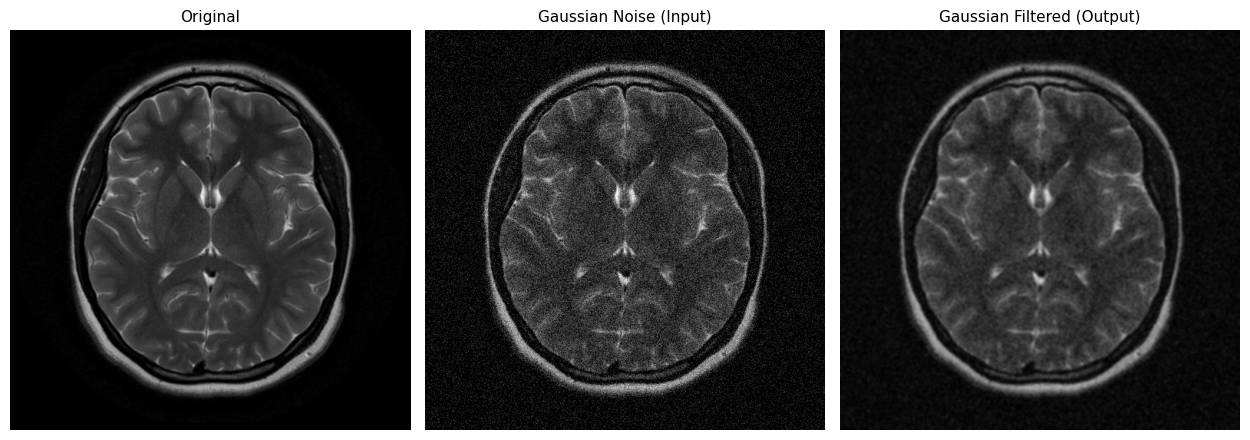

PSNR noisy    vs original: 21.75 dB
PSNR filtered vs original: 28.81 dB


In [ ]:
img2 = load_gray('image2.jpg')

noisy2 = add_gaussian_noise(img2, mean=0, sigma=25)

# Gaussian filtering: a low-pass filter that smooths out the random intensity variation
gaussian_filtered = cv2.GaussianBlur(noisy2, (5, 5), sigmaX=1.5)

show_images([img2, noisy2, gaussian_filtered],
            ['Original', 'Gaussian Noise (Input)', 'Gaussian Filtered (Output)'])

print(f"PSNR noisy    vs original: {psnr(img2, noisy2):.2f} dB")
print(f"PSNR filtered vs original: {psnr(img2, gaussian_filtered):.2f} dB")

---
## Problem 3 — Box vs Weighted Average vs Median Filtering

Salt-and-pepper noise is used here because it best exposes the difference between **linear** filters (box, weighted average) and the **non-linear** median filter.

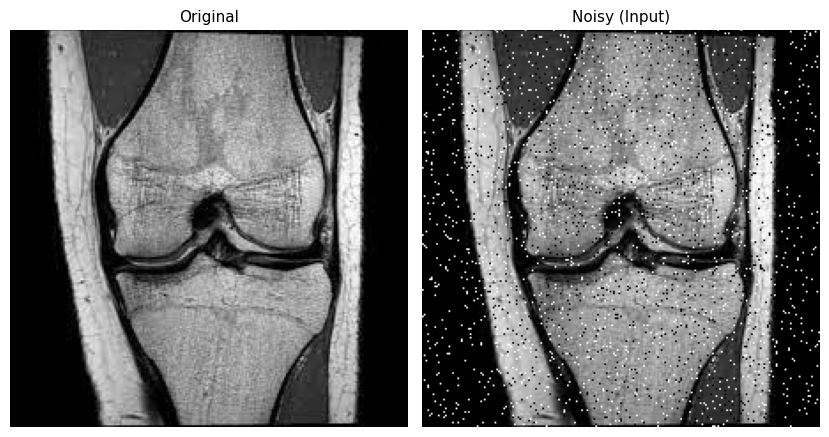

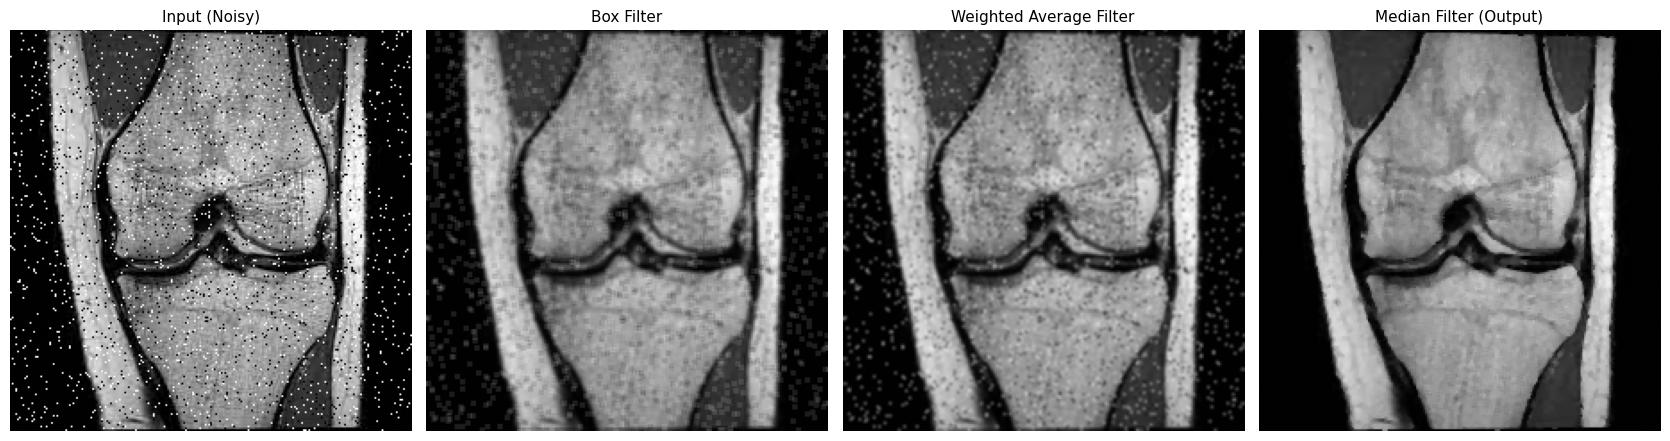

PSNR - Box filter:              22.51 dB
PSNR - Weighted average filter: 22.88 dB
PSNR - Median filter:           26.35 dB

Highest PSNR on this image: Median filter (26.35 dB)


In [ ]:
img3 = load_gray('image3.jpg')

noisy3 = add_salt_pepper_noise(img3, salt_prob=0.03, pepper_prob=0.03)

# 1) Box filtering: plain, unweighted 3x3 average
box_kernel = np.ones((3, 3), np.float32) / 9
box_filtered = cv2.filter2D(noisy3, -1, box_kernel)

# 2) Weighted average filtering: centre pixel weighted more heavily than its neighbours
weighted_kernel = np.array([[1, 2, 1],
                             [2, 4, 2],
                             [1, 2, 1]], np.float32) / 16
weighted_filtered = cv2.filter2D(noisy3, -1, weighted_kernel)

# 3) Median filtering: replaces each pixel with the median of its 3x3 neighbourhood
median_filtered = cv2.medianBlur(noisy3, 3)

show_images([img3, noisy3], ['Original', 'Noisy (Input)'])
show_images([noisy3, box_filtered, weighted_filtered, median_filtered],
            ['Input (Noisy)', 'Box Filter', 'Weighted Average Filter', 'Median Filter (Output)'])

p_box = psnr(img3, box_filtered)
p_wavg = psnr(img3, weighted_filtered)
p_med = psnr(img3, median_filtered)

print(f"PSNR - Box filter:              {p_box:.2f} dB")
print(f"PSNR - Weighted average filter: {p_wavg:.2f} dB")
print(f"PSNR - Median filter:           {p_med:.2f} dB")

best = max([('Box', p_box), ('Weighted Average', p_wavg), ('Median', p_med)], key=lambda x: x[1])
print(f"\nHighest PSNR on this image: {best[0]} filter ({best[1]:.2f} dB)")

**Why this usually turns out the way it does:** box and weighted-average filters are *linear* — they blend the corrupted 0/255 pixel value into the average of its neighbourhood, which spreads the error around (and blurs edges, box more than weighted-average since it doesn't favour the centre pixel). The median filter is *non-linear* — for impulse noise, the corrupted pixel is almost always the min or max in its neighbourhood, so the median simply ignores it and edges stay sharp. That's why median filtering generally wins on salt-and-pepper noise specifically; for other noise types (e.g. Gaussian) this ranking does not necessarily hold. Confirm the actual winner for your image using the printed PSNR values above.

---
## Problem 4 — Sharpening: Unsharp Masking vs High Boost Filtering

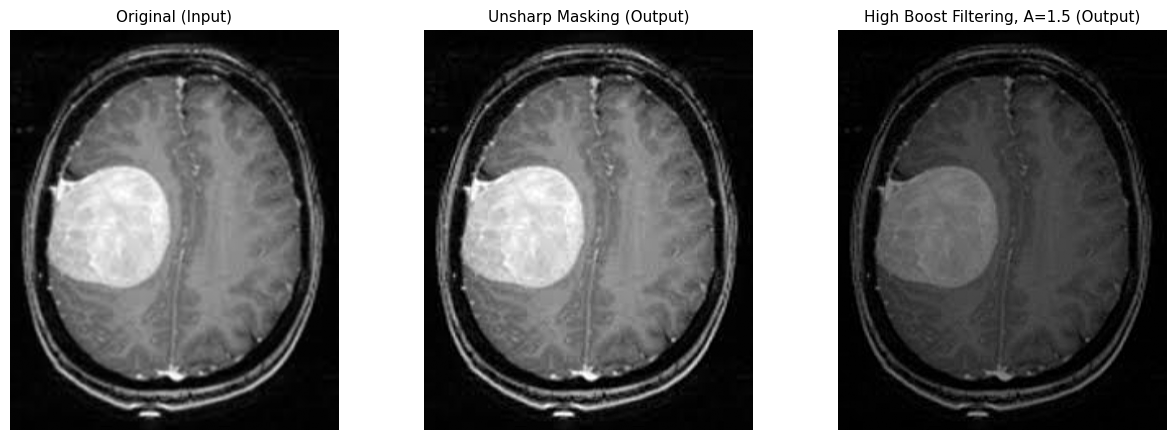

Sharpness (Laplacian variance) - Original:            35.29
Sharpness (Laplacian variance) - Unsharp Masking:      75.29
Sharpness (Laplacian variance) - High Boost (A=1.5):   34.83


In [ ]:
img4 = load_gray('image4.png')

def unsharp_masking(image, ksize=(5, 5), sigma=1.0, k=1.0):
    blurred = cv2.GaussianBlur(image, ksize, sigma)
    mask = image.astype(np.float64) - blurred.astype(np.float64)
    sharpened = image.astype(np.float64) + k * mask
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def high_boost_filter(image, ksize=(5, 5), sigma=1.0, A=1.5):
    blurred = cv2.GaussianBlur(image, ksize, sigma)
    boosted = A * image.astype(np.float64) - blurred.astype(np.float64)
    return np.clip(boosted, 0, 255).astype(np.uint8)

unsharp_result = unsharp_masking(img4, k=1.0)
highboost_result = high_boost_filter(img4, A=1.5)

show_images([img4, unsharp_result, highboost_result],
            ['Original (Input)', 'Unsharp Masking (Output)', 'High Boost Filtering, A=1.5 (Output)'])

# Sharpness proxy: variance of the Laplacian (higher = more high-frequency detail)
def sharpness_score(image):
    return cv2.Laplacian(image, cv2.CV_64F).var()

s_orig = sharpness_score(img4)
s_unsharp = sharpness_score(unsharp_result)
s_highboost = sharpness_score(highboost_result)

print(f"Sharpness (Laplacian variance) - Original:            {s_orig:.2f}")
print(f"Sharpness (Laplacian variance) - Unsharp Masking:      {s_unsharp:.2f}")
print(f"Sharpness (Laplacian variance) - High Boost (A=1.5):   {s_highboost:.2f}")

**Note:** High boost filtering (`A > 1`) generalizes unsharp masking — it keeps more of the original image while still adding back the high-frequency mask, so increasing `A` gives you a dial between "subtle" and "aggressive" sharpening. A higher Laplacian-variance score means more edge energy, but past a point it also means visible halos/noise amplification — check both the numbers above and the images visually before deciding which is "better" for this image.

---
## Problem 5 — Sharpening Using Laplacian Filtering

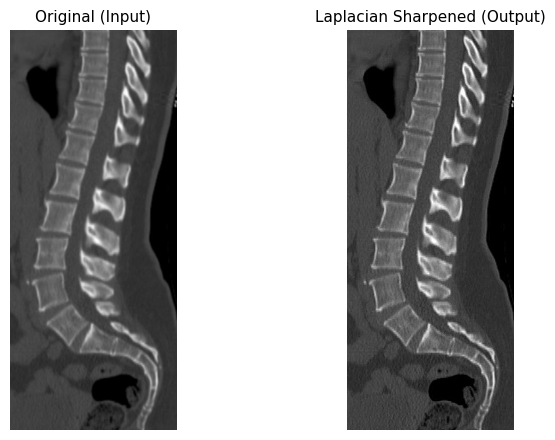

In [ ]:
img5 = load_gray('image5.png')

laplacian_kernel = np.array([[0,  1, 0],
                              [1, -4, 1],
                              [0,  1, 0]], np.float32)

laplacian5 = cv2.filter2D(img5, cv2.CV_64F, laplacian_kernel)

# This kernel's centre coefficient is negative, so: sharpened = original - laplacian
sharpened5 = img5.astype(np.float64) - laplacian5
sharpened5 = np.clip(sharpened5, 0, 255).astype(np.uint8)

show_images([img5, sharpened5], ['Original (Input)', 'Laplacian Sharpened (Output)'])

---
## Problem 6 — Edge Detection: Roberts Cross, Sobel, Prewitt

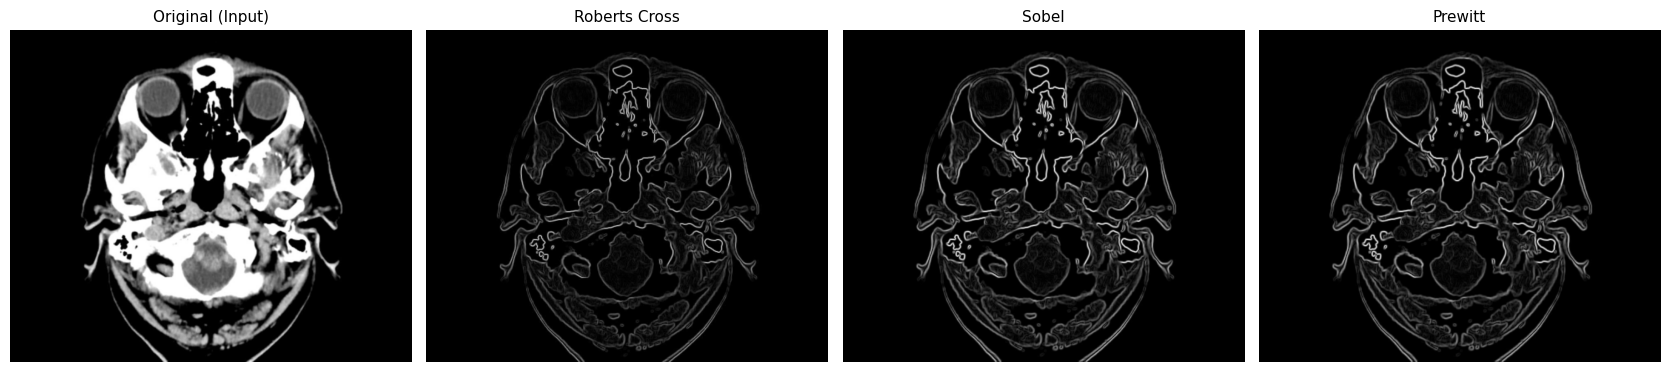

In [ ]:
img6 = load_gray('image6.png')
img6_f = img6.astype(np.float64)

def edge_magnitude(image_f, kx, ky):
    gx = cv2.filter2D(image_f, cv2.CV_64F, kx)
    gy = cv2.filter2D(image_f, cv2.CV_64F, ky)
    mag = np.sqrt(gx ** 2 + gy ** 2)
    mag = (mag / mag.max()) * 255  # normalize to 0-255 for display
    return mag.astype(np.uint8)

# Roberts Cross (2x2 diagonal kernels)
roberts_kx = np.array([[1, 0], [0, -1]], np.float32)
roberts_ky = np.array([[0, 1], [-1, 0]], np.float32)
roberts_edges = edge_magnitude(img6_f, roberts_kx, roberts_ky)

# Sobel (3x3, weights the centre row/column more -> less noise-sensitive)
sobel_kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], np.float32)
sobel_ky = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], np.float32)
sobel_edges = edge_magnitude(img6_f, sobel_kx, sobel_ky)

# Prewitt (3x3, equal weights -> simpler, slightly noisier than Sobel)
prewitt_kx = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], np.float32)
prewitt_ky = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], np.float32)
prewitt_edges = edge_magnitude(img6_f, prewitt_kx, prewitt_ky)

show_images([img6, roberts_edges, sobel_edges, prewitt_edges],
            ['Original (Input)', 'Roberts Cross', 'Sobel', 'Prewitt'])

**Comparing the three:** Roberts Cross uses a tiny 2x2 kernel, so it's fast but noticeably more sensitive to noise and picks up diagonal edges most strongly. Sobel and Prewitt are both 3x3; Sobel's extra centre-row/column weighting (the 2's) gives it some built-in smoothing, so it's usually a bit less noisy than Prewitt while still detecting edges clearly in both directions.